  0%|          | 0/501 [00:00<?, ?it/s]

100%|██████████| 501/501 [00:05<00:00, 86.75it/s] 
/var/folders/pr/qny_rwwj2256n07fx_ml0r500000gn/T/ipykernel_22808/915833027.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


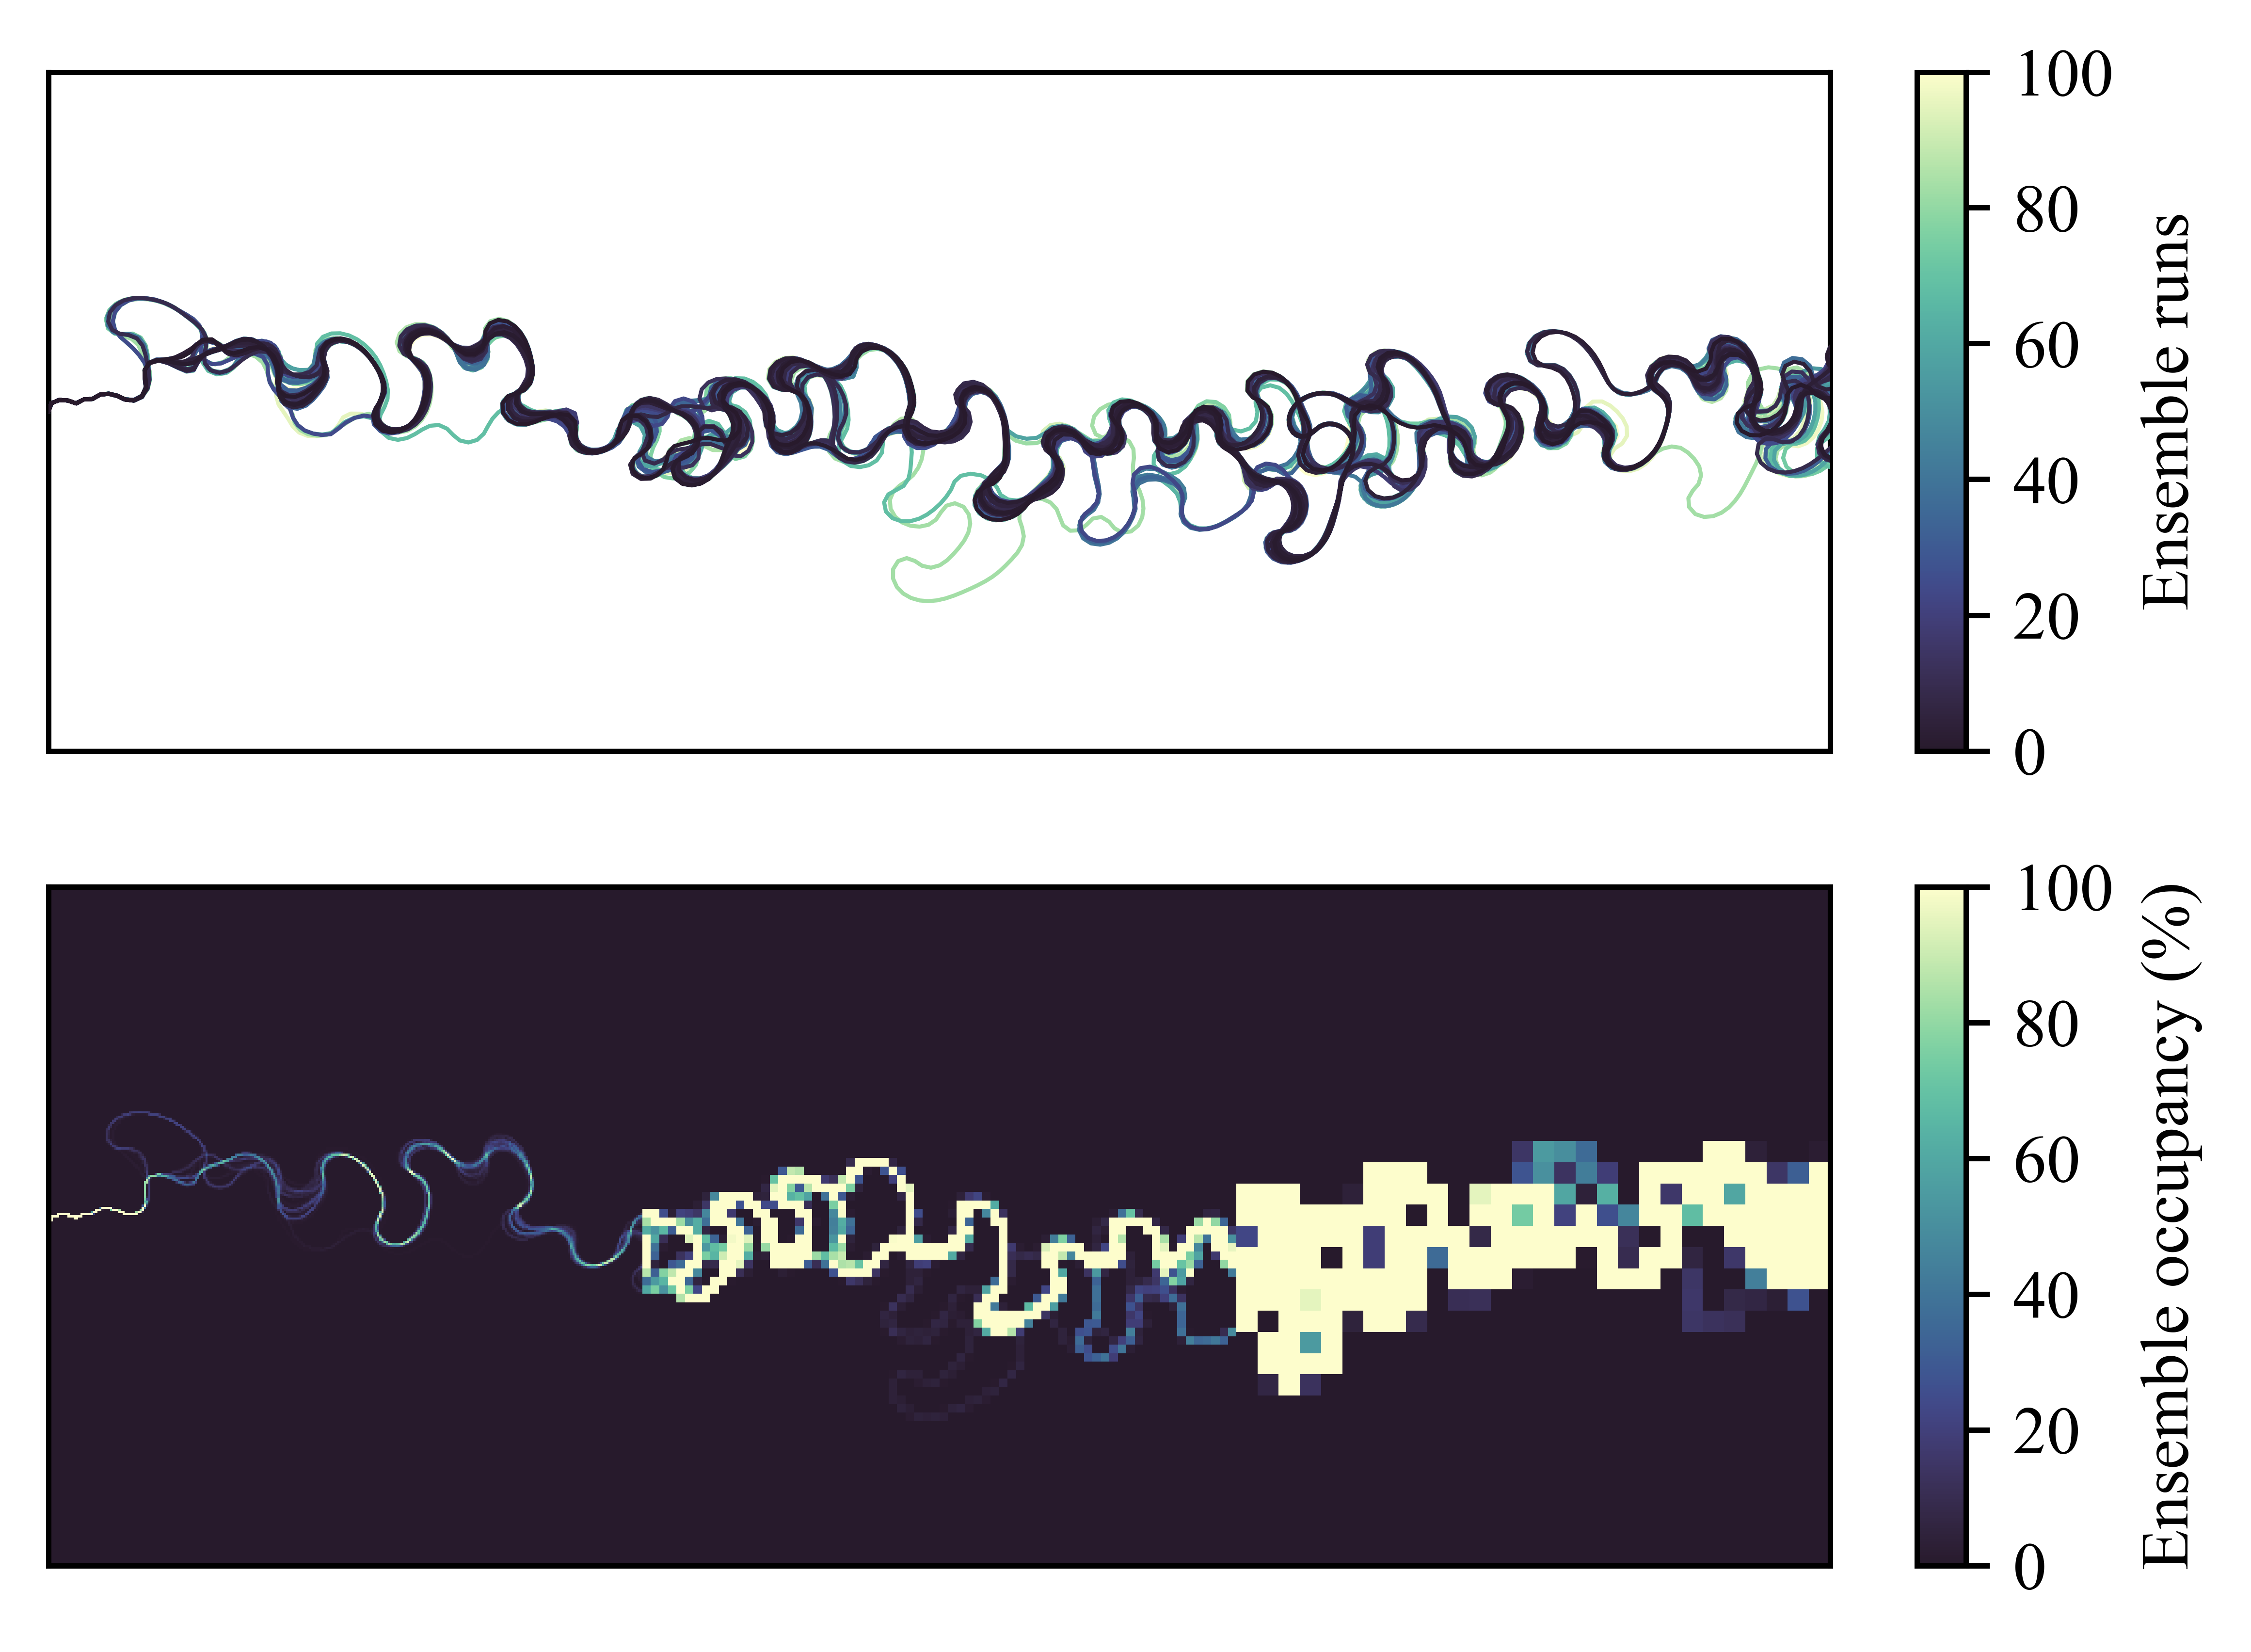

In [ ]:
import numpy as np
import meanderpy as mp
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import interp1d
import cmocean
mpl.rcParams['figure.dpi'] = 1000

def uniform_resample(x, y, z, ds):
    s = np.concatenate(([0.0], np.cumsum(np.hypot(np.diff(x), np.diff(y)) + np.abs(np.diff(z)))))
    s_new = np.arange(0.0, s[-1], ds)
    return np.interp(s_new, s, x), np.interp(s_new, s, y), np.interp(s_new, s, z)

def meander(freq, amp, delta_y, n_pert=1, nit_total=501, reset_interval=501, saved_ts=1, seed=None):
    rng = np.random.default_rng(seed)
    W, D = 50.0, 1.0
    x0 = np.linspace(0.1, 20000, 3000)
    y0 = amp * 100.0 * np.sin(freq * np.pi * x0 / 10_000.0)
    z0 = np.zeros_like(x0)

    ch_ref = mp.Channel(x0.copy(), y0.copy(), z0.copy(), W, D)
    cb_ref = mp.ChannelBelt([ch_ref], [], [0.0], [])

    cb_pert = []
    for _ in range(n_pert):
        y1 = y0.copy()
        y1[rng.integers(1, len(y1) - 1)] += delta_y
        cb_pert.append(mp.ChannelBelt([mp.Channel(x0.copy(), y1, z0.copy(), W, D)], [], [0.0], []))

    depths = D * np.ones(nit_total)
    Cfs = 0.0065 * np.ones(nit_total)
    crdist, pad, deltas = 5 * W, 0, 50.0
    year = 365 * 24 * 60 * 60
    kl, kv, dt, dens = 500.0 / year, 1e-12, 0.05 * year, 1000
    t1 = t2 = t3 = aggr = 0

    pert_channels = [[belt.channels[0]] for belt in cb_pert]
    steps = 0
    while steps < nit_total:
        n = min(reset_interval, nit_total - steps)
        cb_ref.migrate(n, saved_ts, deltas, pad, crdist, depths[steps:steps+n], Cfs[steps:steps+n], kl, kv, dt, dens, t1, t2, t3, aggr)
        for belt in cb_pert:
            belt.migrate(n, saved_ts, deltas, pad, crdist, depths[steps:steps+n], Cfs[steps:steps+n], kl, kv, dt, dens, t1, t2, t3, aggr)
        for i, belt in enumerate(cb_pert):
            pert_channels[i].extend(belt.channels[1:])
        steps += n
        if steps == nit_total: break

        last = cb_ref.channels[-1]
        ds_target = W / 2.0
        for i in range(n_pert):
            y_seed = last.y.copy()
            y_seed[rng.integers(1, len(y_seed) - 1)] += delta_y
            x_u, y_u, z_u = uniform_resample(last.x, y_seed, last.z, ds_target)
            cb_pert[i] = mp.ChannelBelt([mp.Channel(x_u, y_u, z_u, W, D)], [], [0.0], [])
            pert_channels[i].append(cb_pert[i].channels[0])

    return pert_channels

# run
pert_chs_list = meander(freq=30.0, amp=3.0, delta_y=1e-10, n_pert=100, nit_total=501, seed=42)

# plotting
plt.rcParams["font.family"] = "Times New Roman"
x0, x1, y0, y1 = 100.0, 310.0, -40.0, 40.0

def transform_xy(x, y): return x / 50.0 + 100.0, y / 50.0

def densify_polyline(x, y, step):
    if len(x) < 2: return x, y
    s = np.concatenate(([0.0], np.cumsum(np.hypot(np.diff(x), np.diff(y)))))
    if s[-1] == 0: return x, y
    s_new = np.arange(0.0, s[-1] + 1e-9, step)
    return np.interp(s_new, s, x), np.interp(s_new, s, y)

def count_cells_touched_fine(pert_chs_list, t, x0, x1, y0, y1, cell):
    nx, ny = int(np.ceil((x1 - x0) / cell)), int(np.ceil((y1 - y0) / cell))
    counts = np.zeros((ny, nx), dtype=np.uint16)
    for run in pert_chs_list:
        x, y = transform_xy(run[t].x, run[t].y)
        x, y = densify_polyline(x, y, cell / 4.0)
        m = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
        if not m.any(): continue
        xi = np.clip(np.floor((x[m] - x0) / cell).astype(int), 0, nx - 1)
        yi = np.clip(np.floor((y[m] - y0) / cell).astype(int), 0, ny - 1)
        np.add.at(counts.ravel(), np.unique(yi * nx + xi), 1)
    return counts, nx, ny

def aggregate_counts(a, fx, fy):
    ny, nx = a.shape
    a = a[: (ny // fy) * fy, : (nx // fx) * fx]
    return a.reshape(ny // fy, fy, a.shape[1] // fx, fx).sum(axis=(1, 3))

timestep, cell_fine = 300, 0.25
counts_fine, nx_f, ny_f = count_cells_touched_fine(pert_chs_list, timestep, x0, x1, y0, y1, cell_fine)

fig = plt.figure(figsize=(6, 4))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[50, 1], wspace=-0.2)
ax_top, cax_top, ax_bot, cax_bot = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

N = len(pert_chs_list)
colors = cmocean.cm.deep(np.linspace(0, 1, N))
order = np.argsort(0.2126*colors[:,0] + 0.7152*colors[:,1] + 0.0722*colors[:,2])[::-1]
for rank, i in enumerate(order):
    xx, yy = transform_xy(pert_chs_list[i][timestep].x, pert_chs_list[i][timestep].y)
    ax_top.plot(xx, yy, lw=0.6, color=colors[i], zorder=100+rank)

norm_top = Normalize(vmin=1, vmax=N)
cb_top = fig.colorbar(plt.cm.ScalarMappable(cmap=cmocean.cm.deep_r, norm=norm_top), cax=cax_top)
cb_top.set_label("Ensemble runs")
cb_top.set_ticks(np.linspace(1, N, 6))
cb_top.set_ticklabels(["0", "20", "40", "60", "80", "100"])

norm_bot = Normalize(vmin=0, vmax=N)
cmap_bot = cmocean.cm.deep_r
XW = x1 - x0; xL, xM, xR = x0, x0 + XW/3.0, x0 + 2*XW/3.0
x_to_ix = lambda x: int(np.clip(np.floor((x - x0) / cell_fine), 0, nx_f))

sub_L  = counts_fine[:, x_to_ix(xL):x_to_ix(xM)]
sub_M  = aggregate_counts(counts_fine[:, x_to_ix(xM):x_to_ix(xR)], fx=4,  fy=4)
sub_R  = aggregate_counts(counts_fine[:, x_to_ix(xR):x_to_ix(x1)], fx=10, fy=10)

ax_bot.imshow(sub_L, extent=[xL, xM, y0, y1], origin='lower', interpolation='nearest', cmap=cmap_bot, norm=norm_bot)
ax_bot.imshow(sub_M, extent=[xM, xR, y0, y1], origin='lower', interpolation='nearest', cmap=cmap_bot, norm=norm_bot)
ax_bot.imshow(sub_R, extent=[xR, x1, y0, y1], origin='lower', interpolation='nearest', cmap=cmap_bot, norm=norm_bot)

cb_bot = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_bot, norm=norm_bot), cax=cax_bot)
cb_bot.set_label("Ensemble occupancy (%)")
cb_bot.set_ticks([0, 20, 40, 60, 80, 100])

for ax in (ax_top, ax_bot):
    ax.set_xlim([x0, x1]); ax.set_ylim([y0, y1]); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()